In [1]:
import numpy as np
import netCDF4 as nc
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


In [2]:
def extract_his_2d(vars,ilats,ilons,fn_his):
    data_out = dict()
    nlt = len(ilats)
    with nc.Dataset(fn_his) as ds:
        t1 = ds.variables['ocean_time'][:]
        data_out['ocean_time'] = t1.data[:]
        nt = len(t1)
        for var in vars:
            his2d = np.zeros((nt,nlt))
            for ii in np.arange(nlt):
                his2d[:,ii] = ds.variables[var][:,ilats[ii],ilons[ii]].data
            
            data_out[var] = his2d
 
    return data_out

def dlat_to_dy(dlat,alat):
#
# dy   = latitude difference in meters
# dlat = latidute difference in degrees
# alat = average latitude between the two fixes
# Reference: American Practical Navigator, Vol II, 1975 Edition, p 5

    rlat = alat * np.pi/180
    m = (111132.09 * rlat - 
        566.05 * np.cos(2 * rlat) + 1.2 * np.cos(4 * rlat) )
    dy = m * dlat
    return dy

def dlon_to_dx(dlon,alat):
#
# dlon = longitude difference in degrees
# dx   = longitude difference in meters
# alat = average latitude between the two fixes

    rlat = alat * np.pi/180
    p = 111415.13 * np.cos(rlat) - 94.55 * np.cos(3 * rlat)
    dx = p * dlon 
    return dx


def get_lat_lon_indices(lats,lons,lvl):
    if lvl == 'LV1':
        fn_grd = '/dataSIO/PFM_Simulations/Grid/GRID_SDTJRE_LV1_rx020_hmask.nc'
    elif lvl == 'LV2':
        fn_grd = '/dataSIO/PFM_Simulations/Grid/GRID_SDTJRE_LV2_rx020.nc'
    elif lvl == 'LV3':
        fn_grd = '/dataSIO/PFM_Simulations/Grid/GRID_SDTJRE_LV3_rx020.nc'
    elif lvl == 'LV4':
        fn_grd = '/dataSIO/PFM_Simulations/Grid/GRID_SDTJRE_LV4_mss_oct2024.nc'

    with nc.Dataset(fn_grd) as ds:
        latg = ds.variables['lat_rho'][:]
        long = ds.variables['lon_rho'][:]
        mask_rho = ds.variables['mask_rho'][:]

    bar_lat = np.mean(latg)
    bar_lon = np.mean(long)
    xg = dlon_to_dx(long-bar_lon,bar_lat)
    yg = dlat_to_dy(latg-bar_lat,bar_lat)

    x0 = dlon_to_dx(lons-bar_lon,bar_lat)
    y0 = dlat_to_dy(lats-bar_lat,bar_lat)    

    cnt = 0
    ilt = []
    iln = []
    for y in y0:
        x = x0[cnt]
        dy = yg-y
        dx = xg-x
        D2 = np.square(dx) + np.square(dy)
        # Find the flattened index of the minimum value
        min_flat_index = np.argmin(D2)

        # Convert the flattened index to (row, column) indices
        row_index, col_index = np.unravel_index(min_flat_index, D2.shape)
        
        # check and see if mask_rho is 1 (ocean) here...
        land = True
        while land:
            msk = mask_rho[row_index,col_index]
            if msk == 1:
                land = False
                print('the (lat,lon) requested was: ',lats[cnt],',',lons[cnt])
                print('the (lat,lon) found is: ',latg[row_index,col_index],',',long[row_index,col_index])
            else:
                # move offshore and south!
                print('the lat,lon requested is land. moving offshore and south by 1')
                row_index = row_index - 1
                col_index = col_index - 1

        ilt.append(row_index)
        iln.append(col_index)

        cnt += 1    


    return ilt,iln

In [3]:

lats = [32.50,32.55]
lons = [-117.2,-117.2]
var = 'zeta'
t1 = '20241011' # start time of first file
t2 = '20241013' # start time of last file



In [5]:
ilt3,iln3 = get_lat_lon_indices(lats,lons,'LV3')
print(ilt3,iln3)


the (lat,lon) requested was:  32.5 , -117.2
the (lat,lon) found is:  32.49941668873491 , -117.20084239467755
the (lat,lon) requested was:  32.55 , -117.2
the (lat,lon) found is:  32.550168363402186 , -117.20043268156094
[np.int64(121), np.int64(146)] [np.int64(165), np.int64(176)]


In [25]:

fn_his = '/scratch/PHM_Simulations/LV3_Forecast/His/LV3_ocean_his_202410110000.nc'
data = extract_his_2d(['zeta'],ilt3,iln3,fn_his)
print(data)


{'ocean_time': array([8.134560e+08, 8.134596e+08, 8.134632e+08, 8.134668e+08,
       8.134704e+08, 8.134740e+08, 8.134776e+08, 8.134812e+08,
       8.134848e+08, 8.134884e+08, 8.134920e+08, 8.134956e+08,
       8.134992e+08, 8.135028e+08, 8.135064e+08, 8.135100e+08,
       8.135136e+08, 8.135172e+08, 8.135208e+08, 8.135244e+08,
       8.135280e+08, 8.135316e+08, 8.135352e+08, 8.135388e+08,
       8.135424e+08]), 'zeta': array([[ 0.50185066,  0.50211072],
       [ 0.26871586,  0.28305018],
       [ 0.05668332,  0.0615006 ],
       [-0.21056521, -0.20437239],
       [-0.45101458, -0.45100191],
       [-0.61687118, -0.62669665],
       [-0.73194546, -0.73574084],
       [-0.7085579 , -0.71516263],
       [-0.58425468, -0.59290928],
       [-0.38698786, -0.39691645],
       [-0.15968435, -0.16983341],
       [ 0.02698023,  0.02014463],
       [ 0.21114144,  0.20765777],
       [ 0.293468  ,  0.28976566],
       [ 0.3216421 ,  0.32572481],
       [ 0.31628534,  0.32033753],
       [ 0.25386

(25, 2)


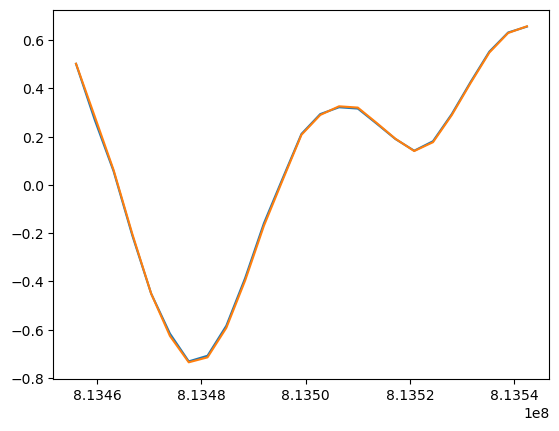

In [26]:

t = data['ocean_time'][:]
zeta = data['zeta'][:]
print(np.shape(zeta))

fig, ax = plt.subplots()
ax.plot(t,zeta)



In [23]:
fn = '/dataSIO/PFM_Simulations/Archive/LV4_His/LV4_ocean_his_202509240600.nc'
fn_gr = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc'
with nc.Dataset(fn) as ds:
    s_w = ds.variables['s_w'][:].data
    Cs_w = ds.variables['Cs_w'][:].data
    zeta = ds.variables['zeta'][:].data
    pn = ds.variables['pn'][:].data
    pm = ds.variables['pm'][:].data
    time = ds.variables['ocean_time'][:].data
    print(ds)

with nc.Dataset(fn_gr) as ds_gr:
    hb = ds_gr.variables['h'][:].data


<class 'netCDF4.Dataset'>
root group (NETCDF3_64BIT_OFFSET data model, file format NETCDF3):
    file: /scratch/PFM_Simulations/LV4_Forecast/His/LV4_ocean_his_202509240600.nc
    format: netCDF-3 64bit offset file
    Conventions: CF-1.4, SGRID-0.3
    type: ROMS/TOMS history file
    title: LV4_PFM_Coawst_Forecast
    var_info: /scratch/PFM_Simulations/LV4_Forecast/Run/LV4_coawst_varinfo.dat
    rst_file: /scratch/PFM_Simulations/restart_data/LV4_ocean_rst_202509240600_202509290600.nc
    his_file: /scratch/PFM_Simulations/LV4_Forecast/His/LV4_ocean_his_202509240600.nc
    grd_file: /scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc
    ini_file: /scratch/PFM_Simulations/restart_data/LV4_ocean_rst_202509230600_202509280600.nc
    frc_file_01: /scratch/PFM_Simulations/LV4_Forecast/Forc/LV4_ATM_FORCING.nc
    bry_file_01: /scratch/PFM_Simulations/LV4_Forecast/Forc/LV4_OCEAN_BC.nc
    clm_file_01: /scratch/PFM_Simulations/LV4_Forecast/Forc/LV4_clm.nc
    nud_file: /scratch/PFM

(11, 1141, 486)
(10, 1141, 486)
(1141, 486)
(10, 1141, 486)
[[24.02771756 24.40128991 24.33518505 24.42058155 24.61575785 24.93221433
  25.08969503 25.2438429  25.39012257 25.41677663]
 [24.02768434 24.35334415 24.32138023 24.39761386 24.58786329 24.92222964
  25.08381428 25.24381476 25.3516109  25.41675103]
 [24.00087009 24.27827152 24.29423962 24.32607255 24.56041961 24.85214584
  25.01419533 25.21563477 25.32330992 25.38837188]
 [23.93591024 24.20328482 24.26710378 24.25462246 24.53298761 24.69633431
  24.9446837  25.16478967 25.29502075 25.36000853]
 [23.86026173 24.1536596  24.24000462 24.1832934  24.48827754 24.66876011
  24.87530944 25.03346906 25.1441761  25.33169172]
 [23.78465826 24.12663418 24.19281805 24.12322109 24.29280512 24.6411694
  24.80065746 24.96461945 25.07587474 25.2271498 ]
 [23.7089837  24.09946278 24.04671763 24.04071252 24.26545477 24.43241466
  24.73665616 24.92864199 25.03866565 25.10642878]
 [23.65726113 24.07220163 23.96193636 23.96939181 24.23801007 24.4

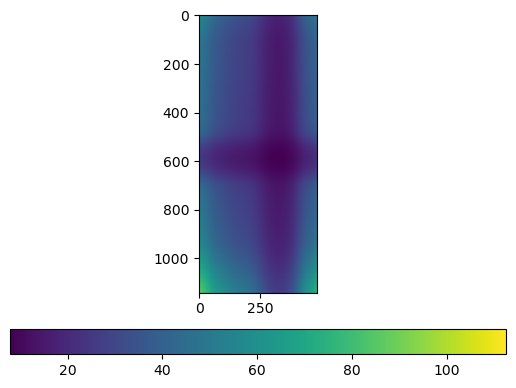

In [ ]:
zeta_1 = np.squeeze( zeta[0,:,:] )
z_w = zeta_1 + (zeta_1 + hb) * Cs_w[:,np.newaxis,np.newaxis]
Hz = np.diff(z_w,axis=0)
Area = 1/(pn*pm + 1e-10)
Volume = Hz * Area 



print(np.shape(z_w))
print(np.shape(Hz))
print(np.shape(Area))
print(np.shape(Volume))
print(np.cbrt( Volume[0,0:10,0:10] ))
print(np.sqrt( Area[0:10,0:10]))

fig, ax = plt.subplots()
im = ax.imshow(np.sqrt( Area) )
plt.colorbar(im, ax=ax, location='bottom', pad=0.1) # pad adjusts distance from image



In [25]:
def get_dye_volumes(fn_his,fn_grd):

    with nc.Dataset(fn_grd) as ds_gr:
        hb = ds_gr.variables['h'][:].data

    with nc.Dataset(fn_his) as ds:
        s_w = ds.variables['s_w'][:].data
        Cs_w = ds.variables['Cs_w'][:].data
        pn = ds.variables['pn'][:].data
        pm = ds.variables['pm'][:].data
        Area = 1/(pn*pm + 1e-10)
        time = ds.variables['ocean_time'][:].data
        time_0 = datetime(1999,1,1)
        t = time_0 + time * timedelta(seconds=1)
        nt = len(time)
        V_dye1 = np.zeros(nt)
        V_dye2 = np.zeros(nt)
        V_tot = np.zeros(nt)
        for ii in np.arange(nt):
            dye1 = ds.variables['dye_01'][ii,:,:,:].data
            dye2 = ds.variables['dye_02'][ii,:,:,:].data
            zeta = ds.variables['zeta'][ii,:,:].data
            msk  = ds.variables['wetdry_mask_rho'][ii,:,:].data 
            z_w = zeta + (zeta + hb) * Cs_w[:,np.newaxis,np.newaxis]
            Hz = np.diff(z_w,axis=0)
            Volume = Hz * Area
            Vd1 = dye1 * Volume
            Vd2 = dye2 * Volume
            Vd1z = np.sum(Vd1,axis=0) # sum in vertical
            Vd2z = np.sum(Vd2,axis=0)
            Vd1z = Vd1z * msk # zero out land
            Vd2z = Vd2z * msk
            V_tot[ii] = np.sum( msk * np.sum(Volume,axis=0) )
            V_dye1[ii] = np.sum(Vd1z)
            V_dye2[ii] = np.sum(Vd2z) 

    return t, V_dye1, V_dye2, V_tot

In [26]:
fn_his = '/dataSIO/PFM_Simulations/Archive/LV4_His/LV4_ocean_his_202509240600.nc'
fn_grd = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc'

t, V_dye1, V_dye2, V_tot = get_dye_volumes(fn_his,fn_grd)


Text(0, 0.5, 'WW Volume [m3]')

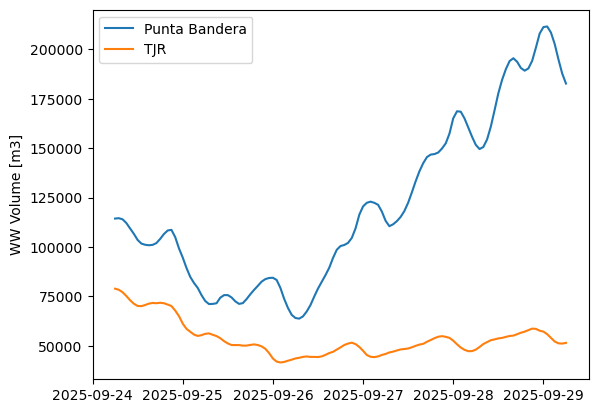

In [30]:
fig, ax = plt.subplots()
ax.plot(t,V_dye1,label='Punta Bandera')
ax.plot(t,V_dye2,label='TJR')
plt.legend()
plt.ylabel('WW Volume [m3]')

In [ ]:


time_0 = datetime(1999,1,1)
t2 = time_0 + time * timedelta(seconds=1)
print(t2)

In [ ]:

Hz = np.diff(z_w)

s_w = ds.variables['s_w'][:].data
Cs_w = ds.variables['Cs_w'][:].data
zeta = ds.variables['zeta'][:].data
hb = ds_gr.variables['h'][:].data


In [ ]:


dum = np.random.rand(7,6)
dum2 = dum[:,[2,4,5]]
print(dum2)